# Elife Paper 
## Figure 7: Lesion Experiment


In [20]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import json
import pickle
# import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
import yaml
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import Environment, NN, params_base, build_and_run
from dual_pathway_model.plotting_functions import plot_colors, save_figure

In [21]:
save_figs = True

In [22]:
wanted_days = [0, 30, 60]
wanted_parameters = ["BG_INTACT_DAYS", "RA_INTACT_DAYS"]

In [23]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Lesion_exp/results"

result_folders = find_subdirectories(results_dir, absolute=True)
selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    if param_name in wanted_parameters:
        selected_folders.append(folder)

print(selected_folders)

BG_INTACT_DAYS
RA_INTACT_DAYS
[WindowsPath('C:/Users/aSuryawanshi/Documents/Codes/Dual_Pathway_RL_songbird/Lesion_exp/results/params_BG_INTACT_DAYS'), WindowsPath('C:/Users/aSuryawanshi/Documents/Codes/Dual_Pathway_RL_songbird/Lesion_exp/results/params_RA_INTACT_DAYS')]


In [24]:
terminal_performance = {}
motor_variability = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    motor_var_path = folder / "terminal_motor_var.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)
    motor_variability[param] = np.load(motor_var_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


In [25]:
print("Available days:", meta['BG_INTACT_DAYS']['values'])
print("Size of terminal performance data:", terminal_performance['BG_INTACT_DAYS'].shape)
print("Size of motor variability data:", motor_variability['BG_INTACT_DAYS'].shape)
print("Size of terminal performance data (RA):", terminal_performance['RA_INTACT_DAYS'].shape)
print("Size of motor variability data (RA):", motor_variability['RA_INTACT_DAYS'].shape)


# Data you already have
data = terminal_performance['BG_INTACT_DAYS']
data_ra = terminal_performance['RA_INTACT_DAYS']
data_motor_var = motor_variability['BG_INTACT_DAYS']
data_motor_var_ra = motor_variability['RA_INTACT_DAYS']
lesion_day_list = meta['BG_INTACT_DAYS']['values']
lesion_day_list_ra = meta['RA_INTACT_DAYS']['values']
print("Wanted days:", wanted_days)
conditions = ['Before Lesion', 'After Lesion', 'Terminal Performance']

Available days: [0.0, 30.0, 60.0]
Size of terminal performance data: (100, 3, 3)
Size of motor variability data: (100, 3, 3)
Size of terminal performance data (RA): (100, 3, 3)
Size of motor variability data (RA): (100, 3, 3)
Wanted days: [0, 30, 60]


In [26]:
# from Dual_Pathway_RL_songbird.Lesion_exp import lesion


def plot_results_violin_conditions(
    data,                     # shape: seeds x lesion_days x conditions
    lesion_day_list,
    wanted_days,
    conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    figsize=(12, 5),
    print_success_rate=True,
    lesion = "BG",
    print_stats = False
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # --- indices ---
    wanted_indices = [lesion_day_list.index(day) for day in wanted_days]
    n_conditions = len(conditions)
    if lesion == "BG":
        colors = ['grey', 'lightsteelblue', 'steelblue']
    if lesion == "RA":
        colors = ['grey', 'goldenrod', 'darkgoldenrod']

    # =======================
    # Figure + Grid
    # =======================
    fig = plt.figure(figsize=figsize, constrained_layout=True)

    gs = fig.add_gridspec(
        2, len(wanted_days),
        height_ratios=[4, 10],  # bar = 40% of violin height
        hspace=0.05,
        wspace=0.15
    )

    for col, (day_idx, day) in enumerate(zip(wanted_indices, wanted_days)):

        ax_bar = fig.add_subplot(gs[0, col])
        ax = fig.add_subplot(gs[1, col], sharey=ax if col > 0 else None)

        # bug corrected already, no need to swap
        swap_indices = [0, 1, 2]
        metric_data = data[:, day_idx, swap_indices]  # seeds x conditions

        # =======================
        # Success rate per condition
        # =======================
        success_rate = np.mean(metric_data > success_threshold, axis=0) * 100

        xpos = np.arange(n_conditions)

        ax_bar.bar(
            xpos,
            success_rate,
            color=colors,
            alpha=0.75,
            width=0.65,
        )

        if print_success_rate:
            for i, val in enumerate(success_rate):
                ax_bar.text(
                    i,
                    val + 3,
                    int(val),
                    ha='center',
                    va='bottom',
                    fontsize=10
                )

        ax_bar.set_ylim(0, 100)
        ax_bar.set_yticks([0, 100])
        ax_bar.tick_params(axis='x', bottom=False, labelbottom=False)

        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['bottom'].set_visible(False)

        if col == 0:
            ax_bar.spines['right'].set_visible(False)
            ax_bar.spines['left'].set_bounds(0, 100)
            ax_bar.yaxis.tick_left()
            ax_bar.set_ylabel('Success Rate (%)', fontsize=15, rotation=90, labelpad=0)
        else:
            ax_bar.spines['left'].set_visible(False)
            ax_bar.spines['right'].set_visible(False)
            ax_bar.set_yticklabels([])
            ax_bar.tick_params(axis='y', length=0)

        # =======================
        # Flatten for seaborn
        # =======================
        plot_data = []
        plot_labels = []
        for j, cond in enumerate(conditions):
            plot_data.append(metric_data[:, j])
            plot_labels.extend([cond] * metric_data.shape[0])

        plot_data = np.concatenate(plot_data)

        # =======================
        # Background success band
        # =======================
        ax.axhspan(
            success_threshold, 1.2,
            alpha=0.25,
            color="grey"
        )

        # =======================
        # Violin
        # =======================
        palette = {
            'Before Lesion': colors[0],
            'After Lesion': colors[1],
            'Terminal Performance': colors[2]
        }

        sns.violinplot(
            x=plot_labels,
            y=plot_data,
            inner=None,
            palette=palette,
            linewidth=0,
            cut=0,
            bw_adjust=0.5,
            width=1,
            ax=ax
        )

        # Clip violins to right half
        for c in ax.collections:
            if hasattr(c, "get_paths"):
                for path in c.get_paths():
                    verts = path.vertices
                    x_center = np.median(verts[:, 0])
                    verts[:, 0] = np.maximum(verts[:, 0], x_center)

        # =======================
        # Strip plot (offset left)
        # =======================
        strip = sns.stripplot(
            x=plot_labels,
            y=plot_data,
            size=3,
            color=plot_colors['violin_plot_colors']['color_strip'],
            alpha=0.9,
            jitter=0.1,
            ax=ax
        )

        for coll in strip.collections:
            offsets = coll.get_offsets()
            offsets[:, 0] -= 0.2
            coll.set_offsets(offsets)

        # =======================
        # Threshold line
        # =======================
        ax.axhline(
            success_threshold, 0.02, .98,
            color='dimgray',
            linestyle='--',
            linewidth=2
        )

        # =======================
        # Axis styling
        # =======================
        k = int(day + 40)

        ax.set_ylim(0, 1.015)
        ax.set_yticks([0, success_threshold, 1])

        ax.set_xlim(-0.45, n_conditions - 0.4)
        ax.set_xticks(np.arange(n_conditions) - 0.05)
        ax.set_xticklabels(
            [f'k-1={k - 1}', f'k={k}', '100'],
            rotation=0, ha='center', fontsize=11
        )
        ax.tick_params(axis='x', which='major', length=0)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if col == 0:
            ax.spines['left'].set_bounds(0, 1)
            ax.set_yticklabels(['0', f'{success_threshold}', '1'], fontsize=11)
            ax.set_ylabel("Terminal Performance", fontsize=16)
        else:
            ax.spines['left'].set_visible(False)
            ax.set_yticklabels([])
            ax.set_ylabel("")

        # =======================
        # X-axis break kink between tick 1 (k) and tick 2 (100)
        # =======================
        trans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
        x_break = 1.5
        dx, dy = 0.015, 0.01
        for xb in [x_break - 0.015, x_break + 0.015]:
            ax.plot([xb - dx, xb + dx], [-dy, dy],
                    transform=trans, color='k', lw=1, clip_on=False)

        # =======================
        # Column xlabel
        # =======================
        ax.set_xlabel(f"Lesion on dph k = {k}", fontsize=16, labelpad=12)

        if print_stats:
            medians = np.median(metric_data, axis=0)
            iqr = [np.percentile(metric_data, 75, axis=0), np.percentile(metric_data, 25, axis=0)]
            print(f"\nStats for lesion at day {day} ({lesion}):")
            for i, median in enumerate(medians):
                print(f"Median for {conditions[i]}: {median*100:.2f} [{iqr[1][i]*100:.2f} - {iqr[0][i]*100:.2f}]")

    return fig




Stats for lesion at day 0 (BG):
Median for Before Lesion: nan [nan - nan]
Median for After Lesion: 39.63 [27.80 - 47.09]
Median for Terminal Performance: 37.82 [28.13 - 47.94]

Stats for lesion at day 30 (BG):
Median for Before Lesion: 92.40 [89.11 - 94.63]
Median for After Lesion: 95.63 [86.33 - 97.71]
Median for Terminal Performance: 93.72 [82.70 - 97.75]

Stats for lesion at day 60 (BG):
Median for Before Lesion: 98.15 [96.68 - 98.83]
Median for After Lesion: 98.12 [95.87 - 99.07]
Median for Terminal Performance: 98.14 [96.02 - 99.08]


C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\394942608.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\394942608.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\394942608.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Figure saved as  Plots\Figure_7b_v2.pdf


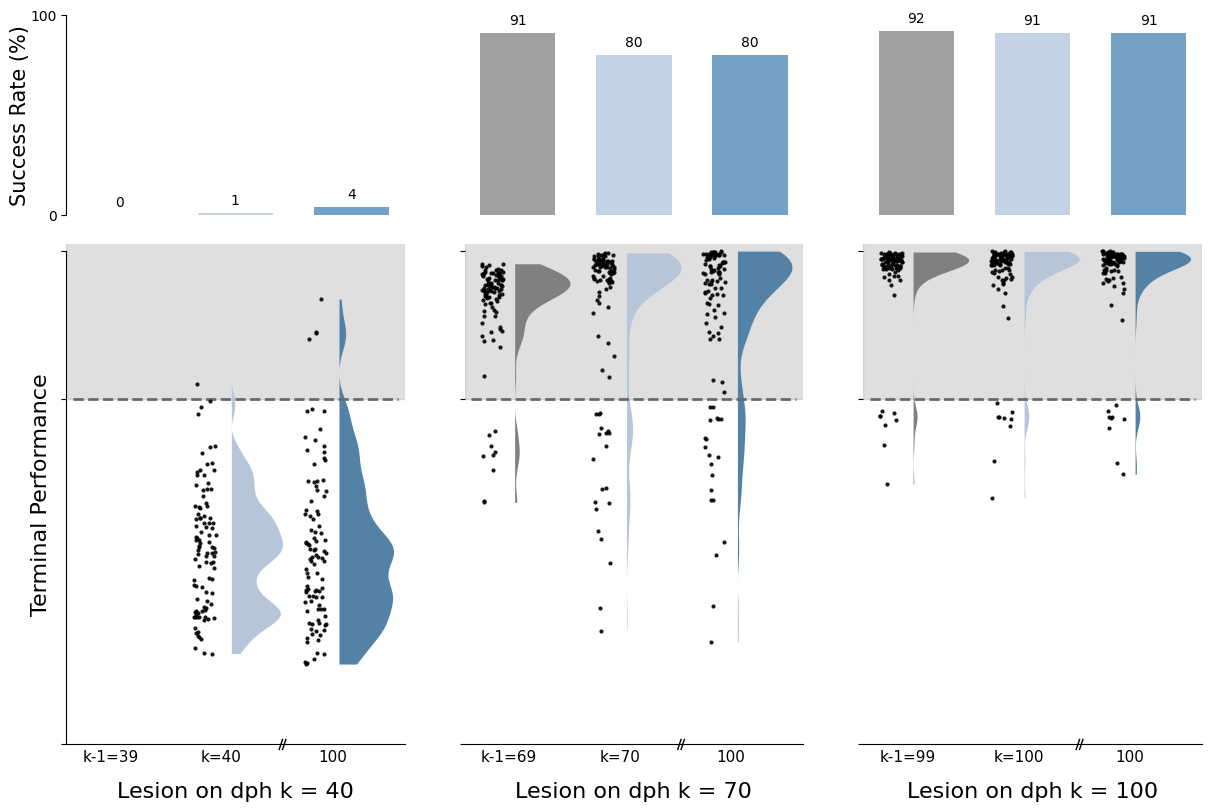

In [27]:

# Call the style-consistent plotting function
fig = plot_results_violin_conditions(
    data=data,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    figsize=(12, 8),
    print_stats = True,
)

save_figure("Figure_7b_v2", save=save_figs)

C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\394942608.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\394942608.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\394942608.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Figure saved as  Plots\Figure_7e_v2.pdf


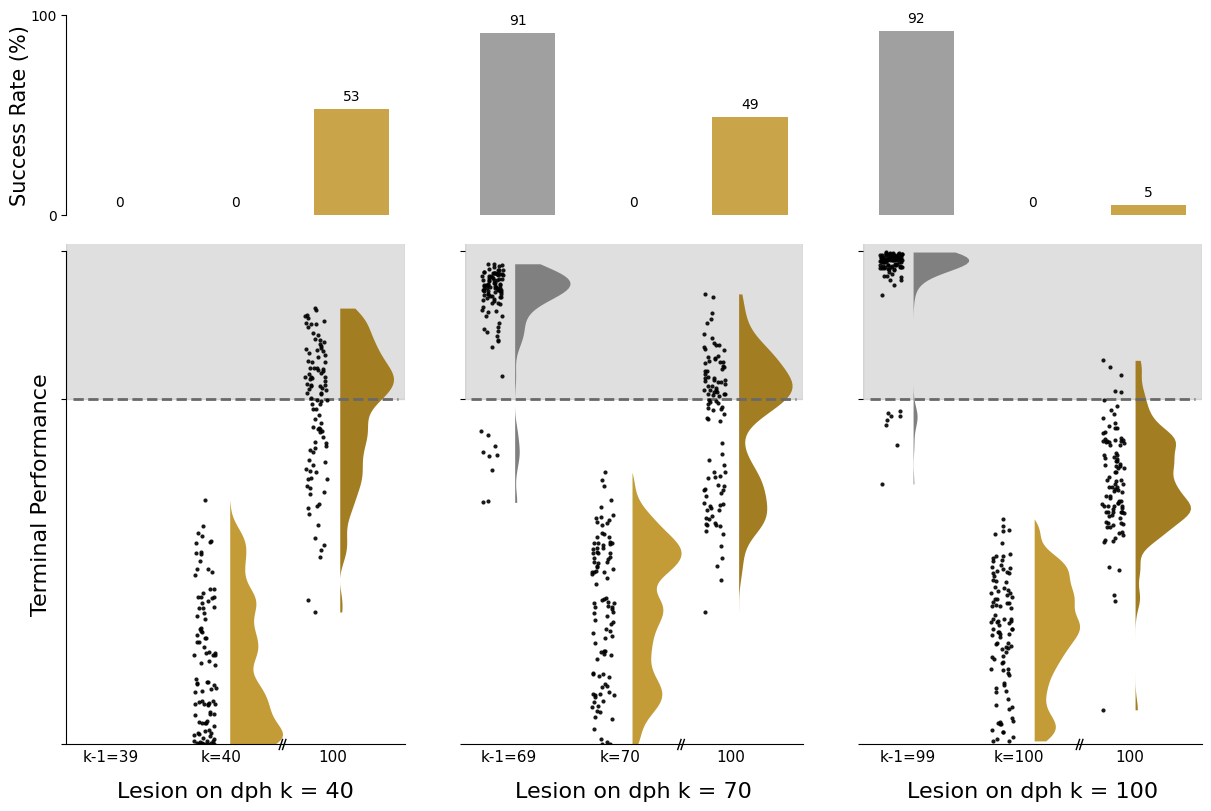

In [28]:

# Call the style-consistent plotting function
fig = plot_results_violin_conditions(
    data=data_ra,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    figsize=(12, 8),
    lesion="RA"
)

save_figure("Figure_7e_v2", save=save_figs)

In [29]:
plot_colors

{'violin_plot_colors': {'color_violin': 'grey',
  'color_bar': 'grey',
  'color_strip': 'black'},
 'colors_pathway': {'palette': 'colorblind',
  'cortical_idx': 0,
  'bg_idx': 1,
  'motor': 'black'}}

In [30]:
data_motor_var.mean(axis=0)

array([[       nan, 0.14599177, 0.05303438],
       [0.1249199 , 0.03568649, 0.0031762 ],
       [0.04501835, 0.0089915 , 0.00836649]])

In [31]:
def plot_motor_var_violin_conditions(
    data,  # shape: seeds x lesion_days x conditions
    lesion_day_list,
    wanted_days,
    conditions,
    plot_colors=plot_colors,
    figsize=(12, 5),
    lesion = "BG",
    print_stats = False
):
    """
    Violin + strip plot for motor variability.

    The y-axis is scaled from the data range with a small padding so the plot
    does not waste vertical space when the values live in a narrow interval.
    """
    wanted_indices = [lesion_day_list.index(day) for day in wanted_days]
    n_conditions = len(conditions)
    if lesion == "BG":
        colors = ['grey', 'lightsteelblue', 'steelblue']
    if lesion == "RA":
        colors = ['grey', 'goldenrod', 'darkgoldenrod']

    swap_indices = [0, 1, 2] # no need to swap 
    reordered_conditions = [conditions[i] for i in swap_indices]
    palette = {
        reordered_conditions[0]: colors[0],
        reordered_conditions[1]: colors[1],
        reordered_conditions[2]: colors[2],
    }

    finite_values = np.asarray(data, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    if finite_values.size:
        y_min = float(np.min(finite_values))
        y_max = float(np.max(finite_values))
        y_pad = 0.08 * (y_max - y_min) if y_max > y_min else max(0.05, abs(y_max) * 0.1)
        y_lower = max(0.0, y_min - y_pad)
        y_upper = y_max + y_pad
    else:
        y_lower, y_upper = 0.0, 1.0

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, len(wanted_days), hspace=0.05, wspace=0.15)

    shared_ax = None

    for col, (day_idx, day) in enumerate(zip(wanted_indices, wanted_days)):
        ax = fig.add_subplot(gs[0, col], sharey=shared_ax)
        if shared_ax is None:
            shared_ax = ax

        metric_data = data[:, day_idx, swap_indices]

        plot_data = []
        plot_labels = []
        for j, cond in enumerate(reordered_conditions):
            values = metric_data[:, j]

            # Keep the first category in the first panel intentionally blank.
            # if col == 0 and j == 0:
            #     values = np.full(values.shape, np.nan, dtype=float)
            # else:
            #     values = values[np.isfinite(values)]

            plot_data.append(values)
            plot_labels.extend([cond] * len(values))

        plot_data = np.concatenate(plot_data)

        sns.violinplot(
            x=plot_labels,
            y=plot_data,
            order=reordered_conditions,
            inner=None,
            palette=palette,
            linewidth=0,
            cut=0,
            bw_adjust=0.5,
            width=1,
            ax=ax,
        )

        for collection in ax.collections:
            if hasattr(collection, "get_paths"):
                for path in collection.get_paths():
                    verts = path.vertices
                    x_center = np.median(verts[:, 0])
                    verts[:, 0] = np.maximum(verts[:, 0], x_center)

        strip = sns.stripplot(
            x=plot_labels,
            y=plot_data,
            order=reordered_conditions,
            size=3,
            color=plot_colors["violin_plot_colors"]["color_strip"],
            alpha=0.9,
            jitter=0.1,
            ax=ax,
        )

        for coll in strip.collections:
            offsets = coll.get_offsets()
            if len(offsets):
                offsets[:, 0] -= 0.2
                coll.set_offsets(offsets)

        k = int(day + 40)

        ax.set_ylim(y_lower, y_upper)
        ax.set_yticks(np.linspace(y_lower, y_upper, 3))
        ax.set_xlim(-0.45, n_conditions - 0.4)
        ax.set_xticks(np.arange(n_conditions) - 0.05)
        ax.set_xticklabels(
            [f"k-1={k - 1}", f"k={k}", "100"],
            rotation=0,
            ha="center",
            fontsize=11,
        )
        ax.tick_params(axis="x", which="major", length=0)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if col == 0:
            ax.spines["left"].set_bounds(y_lower, y_upper)
            ax.set_ylabel("Motor Variability", fontsize=16)
            ax.set_yticklabels([f"{tick:.2f}" for tick in np.linspace(y_lower, y_upper, 3)], fontsize=11)
        else:
            ax.spines["left"].set_visible(False)
            ax.set_yticklabels([])
            ax.set_ylabel("")

        trans = ax.get_xaxis_transform()
        x_break = 1.5
        dx, dy = 0.015, 0.01
        for xb in [x_break - 0.015, x_break + 0.015]:
            ax.plot(
                [xb - dx, xb + dx],
                [-dy, dy],
                transform=trans,
                color="k",
                lw=1,
                clip_on=False,
            )

        ax.set_xlabel(f"Lesion on dph k = {k}", fontsize=16, labelpad=12)

        if print_stats:
            print(f"\nStats for lesion at day {day} ({lesion}):")
            medians = np.median(metric_data, axis=0)
            iqr = [np.percentile(metric_data, 75, axis=0), np.percentile(metric_data, 25, axis=0)]
            for i, median in enumerate(medians):
                print(f"Median for {conditions[i]}: {median:.4f} [{iqr[1][i]:.4f} - {iqr[0][i]:.4f}]")

    return fig



Stats for lesion at day 0 (BG):
Median for Before Lesion: nan [nan - nan]
Median for After Lesion: 0.1457 [0.1440 - 0.1481]
Median for Terminal Performance: 0.0528 [0.0477 - 0.0588]

Stats for lesion at day 30 (BG):
Median for Before Lesion: 0.1119 [0.0913 - 0.1464]
Median for After Lesion: 0.0341 [0.0254 - 0.0433]
Median for Terminal Performance: 0.0009 [0.0003 - 0.0039]

Stats for lesion at day 60 (BG):


C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\2449021031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\2449021031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\2449021031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Median for Before Lesion: 0.0384 [0.0259 - 0.0546]
Median for After Lesion: 0.0072 [0.0028 - 0.0128]
Median for Terminal Performance: 0.0065 [0.0023 - 0.0120]
Figure saved as  Plots\Figure_7c_v2.pdf


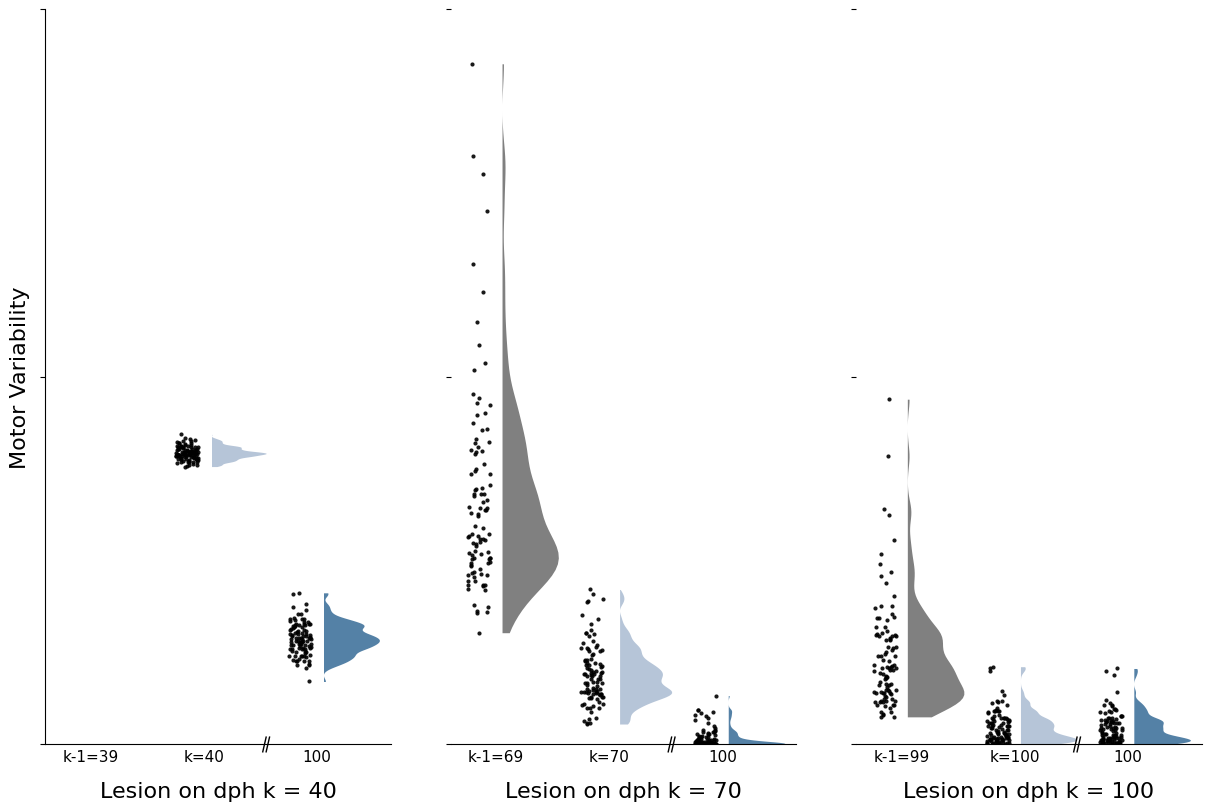

In [32]:

fig = plot_motor_var_violin_conditions(
    data = data_motor_var,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    figsize=(12, 8),
    print_stats=True,
)

save_figure("Figure_7c_v2", save=save_figs)

C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\2449021031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\2449021031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\2449021031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Figure saved as  Plots\Figure_7f_v2.pdf


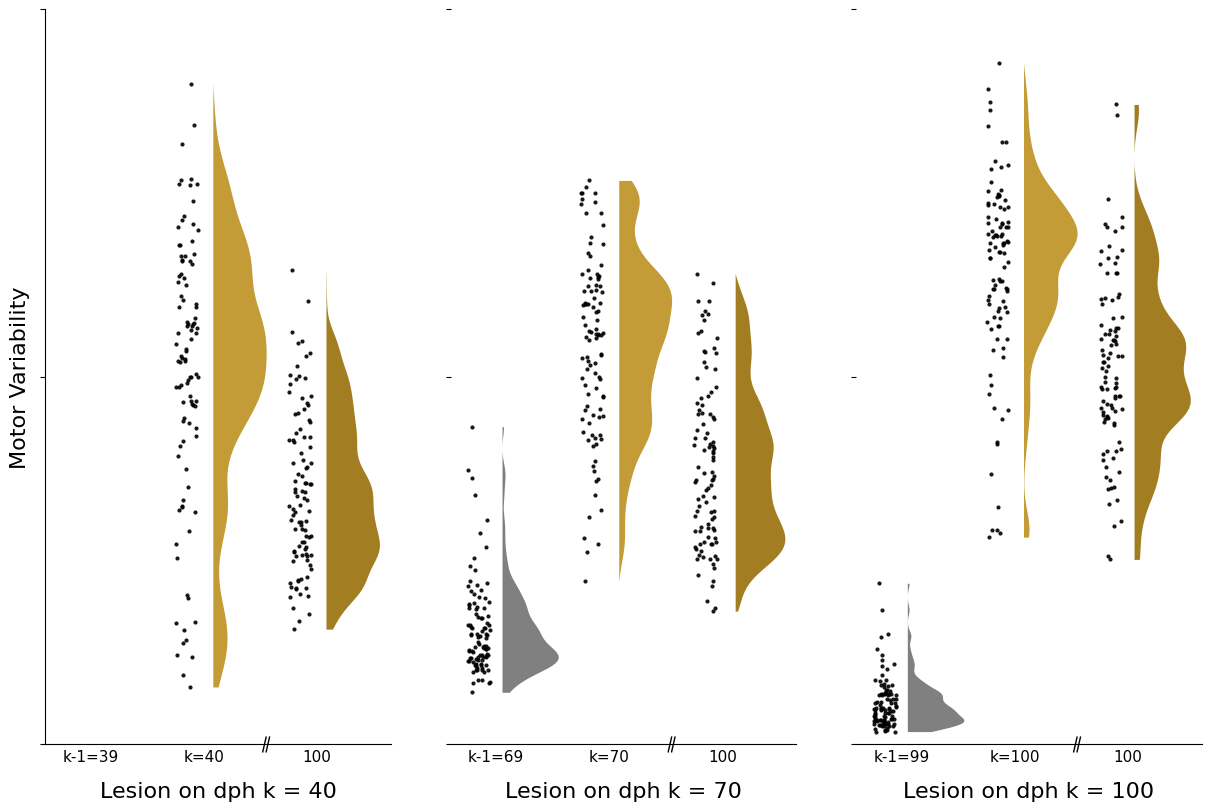

In [33]:

fig = plot_motor_var_violin_conditions(
    data = data_motor_var_ra,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    figsize=(12, 8),
    lesion="RA"
)

save_figure("Figure_7f_v2", save=save_figs)

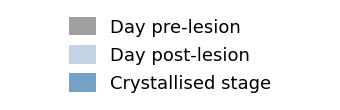

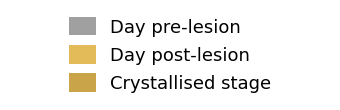

In [34]:
from matplotlib.patches import Patch


# Legend of BG lesion
legend_elements_bg = [
    Patch(facecolor='grey',          alpha=0.75, label='Day pre-lesion'),
    Patch(facecolor='lightsteelblue', alpha=0.75, label='Day post-lesion'),
    Patch(facecolor='steelblue',     alpha=0.75, label='Crystallised stage'),
]

fig_legend, ax_legend = plt.subplots(figsize=(3.5, 1.2))
ax_legend.axis('off')
ax_legend.legend(
    handles=legend_elements_bg,
    loc='center',
    frameon=False,
    fontsize=13,
    handlelength=1.5,
    handleheight=1.2,
)
plt.tight_layout()

# Legend of RA lesion
legend_elements_ra = [
    Patch(facecolor='grey',          alpha=0.75, label='Day pre-lesion'),
    Patch(facecolor='goldenrod', alpha=0.75, label='Day post-lesion'),
    Patch(facecolor='darkgoldenrod',     alpha=0.75, label='Crystallised stage'),
]

fig_legend, ax_legend = plt.subplots(figsize=(3.5, 1.2))
ax_legend.axis('off')
ax_legend.legend(
    handles=legend_elements_ra,
    loc='center',
    frameon=False,
    fontsize=13,
    handlelength=1.5,
    handleheight=1.2,
)
plt.tight_layout()

# save_figure("Figure_7c_legend", format="pdf", save=True)

### B.

In [35]:
HERE = Path.cwd()          # notebook directory
# results_dir = HERE / "../Lesion_exp/results"
LESION_CONFIG = HERE / "../Lesion_exp/lesion_params.yaml"

with open(LESION_CONFIG, "r") as f:
    lesion_cfg = yaml.safe_load(f)

print(f"Lesion parameters loaded from {LESION_CONFIG}")


Lesion parameters loaded from c:\Users\aSuryawanshi\Documents\Codes\Dual_Pathway_RL_songbird\Figures\..\Lesion_exp\lesion_params.yaml


In [36]:

NOS_SEEDS = 1
time_per_iter = 5.5
state = 1158
np.random.seed(state)
seeds = np.random.randint(0, 100000, NOS_SEEDS)
seeds.sort()

# TIME ESTIMATE
total_iterations = sum(len(param_info["values"]) for param_info in lesion_cfg.values()) * NOS_SEEDS
total_time_hours = (total_iterations * time_per_iter) / 3600
print(f"Estimated total time for robustness analysis: {total_time_hours:.2f} hours")

outputs_all = {}
for param_name, param_info in lesion_cfg.items():
    section = param_info["section"]
    values = param_info["values"]
    
    print(f"\nRunning robustness for {section}.{param_name}")

    terminal_performance = np.zeros((NOS_SEEDS, len(values), 3))
    outputs_all[param_name] = []
    for val_idx, val in enumerate(values):
        val = float(val)  # ensure val is a float for YAML serialization
        if val not in wanted_days:
            print(f" -- Skipping {section}.{param_name} = {val} (not in desired_days)")
            continue
        print(f" -- {param_name} = {val}")

        parameters = update_params(
            params_base,
            **{
                f"{section}.{param_name}": val,
                "params.N_SYLL": 1,
                "params.DAYS": 62, # for quick testing
            }
        )

        if parameters["params"]["N_SYLL"] != 1:
            raise ValueError("N_SYLL must be 1 for robustness analysis.")
        for seed_idx, seed in enumerate(seeds):
            outputs = build_and_run(seed, parameters, NN, output_reward = True, output_action= True)
            outputs_all[param_name].append(outputs)


Estimated total time for robustness analysis: 0.01 hours

Running robustness for params.BG_INTACT_DAYS
 -- BG_INTACT_DAYS = 0.0
 Random seed is 20794


100%|██████████| 62/62 [00:06<00:00,  9.77it/s]


 -- BG_INTACT_DAYS = 30.0
 Random seed is 20794


100%|██████████| 62/62 [00:06<00:00,  9.79it/s]


 -- BG_INTACT_DAYS = 60.0
 Random seed is 20794


...

100%|██████████| 62/62 [00:06<00:00,  9.91it/s]


 -- RA_INTACT_DAYS = 30.0
 Random seed is 20794


100%|██████████| 62/62 [00:06<00:00, 10.15it/s]


 -- RA_INTACT_DAYS = 60.0
 Random seed is 20794


100%|██████████| 62/62 [00:06<00:00, 10.03it/s]


In [37]:

result_dict = {}
for param_name in outputs_all:
    result_dict[param_name] = {
        "rewards": [outputs['rewards'] for outputs in outputs_all[param_name]],
        "actions": [outputs['actions'] for outputs in outputs_all[param_name]],
    }

    # rewards_array = []
    # actions_array = []
    # print(f"Processing outputs for {param_name} with {len(outputs_all[param_name])} runs")
    # for outputs in outputs_all[param_name]:
    #     rewards_array.append(outputs['rewards'])
    #     actions_array.append(outputs['actions'])
    # rewards_array = np.array(rewards_array)
    # actions_array = np.array(actions_array)

# print("Rewards array shape:", rewards_array.shape)
# print("Actions array shape:", actions_array.shape)

In [45]:
def plot_rewards_and_actions(rewards, actions, wanted_days, DAYS_TOTAL, TRIALS_TOTAL, smoothing=5):
    # Define colors for the points
    # convert rewards and actions into np arrays
    rewards = np.array(rewards)
    actions = np.array(actions)
    if param_name == "BG_INTACT_DAYS":
        point_colors = {'Before': 'grey', 'After': 'lightsteelblue', 'End': 'steelblue'}
    if param_name == "RA_INTACT_DAYS":
        point_colors = {'Before': 'grey', 'After': 'goldenrod', 'End': 'darkgoldenrod'}
        
    offset = 40
    rewards = rewards.squeeze()  # (params, days, trials)
    actions = actions.squeeze()  # (params, days, trials, 2)

    fig, axs = plt.subplots(3, len(wanted_days), figsize=(4 * len(wanted_days), 4), sharey='row')
    if len(wanted_days) == 1:
        axs = np.expand_dims(axs, axis=1)

    for i, lesion_day in enumerate(wanted_days):
        param_idx = np.where(np.array(wanted_days) == lesion_day)[0][0]
        # print(f"Lesion at day {lesion_day}")

        # Flatten data
        reward_data = rewards[param_idx].reshape(-1)
        action_data = actions[param_idx].reshape(-1, 2)
        time_axis = np.linspace(0, DAYS_TOTAL, DAYS_TOTAL * TRIALS_TOTAL)
        # Stats
        reward_before_lesion = reward_data[(lesion_day-1)*TRIALS_TOTAL:(lesion_day)*TRIALS_TOTAL]
        reward_after_lesion = reward_data[(lesion_day)*TRIALS_TOTAL:(lesion_day+1)*TRIALS_TOTAL]
        reward_terminal = reward_data[-TRIALS_TOTAL:]
        # print(f"Reward before lesion: {reward_before_lesion.mean():.3f}+-{reward_before_lesion.std():.3f}")
        # print(f"Reward after lesion: {reward_after_lesion.mean():.3f}+-{reward_after_lesion.std():.3f}")
        # night jump 
        # night_jump_before = actions[param_idx][lesion_day-3:lesion_day,0] - actions[param_idx][lesion_day-4:lesion_day-1,-1]
        # print(f"Night jump: {night_jump_before.mean():.3f}+-{night_jump_before.std():.3f}")
        night_jump_after = actions[param_idx][lesion_day+1:lesion_day+4,0] - actions[param_idx][lesion_day:lesion_day+3,-1]
        # print(f"Night jump after: {night_jump_after.mean():.3f}+-{night_jump_after.std():.3f}")
        # Smooth data
        smooth_reward = running_mean(reward_data, smoothing)
        smooth_x = running_mean(action_data[:, 0], smoothing)
        smooth_y = running_mean(action_data[:, 1], smoothing)
        # print(f"Actions shape: {actions[param_idx].shape}")
        mean_motor_var = np.mean(np.std(actions[param_idx], axis = 1),axis=1)
        # print(f"Mean motor var shape: {mean_motor_var.shape}")
        smooth_time = time_axis[:len(smooth_reward)] # making sure time axis matches smoothed data length

        # Plot full trajectories in black
        axs[0, i].plot(smooth_time + offset, smooth_reward, color='black', lw=1)
        axs[1, i].plot(smooth_time + offset, smooth_reward, color='black', lw=1)
        axs[0, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)  # type: ignore
        axs[1, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)  # type: ignore
        spacing_with_zoom = 100
        spacing_without_zoom = 100
        axs[0, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_with_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
        axs[0, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL + spacing_with_zoom - 101] + offset, reward_after_lesion.mean(), color=point_colors['After'], s=100, zorder=5)
        axs[1, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_without_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
        axs[1, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL + spacing_without_zoom - 101] + offset, reward_after_lesion.mean(), color=point_colors['After'], s=100, zorder=5)
        axs[0, i].scatter(DAYS_TOTAL+ offset, reward_terminal.mean(), color=point_colors['End'], s=100, zorder=5)
        axs[1, i].scatter(DAYS_TOTAL+ offset, reward_terminal.mean(), color=point_colors['End'], s=100, zorder=5)

        # Formatting
        axs[0, i].set_xlim(offset+lesion_day - 2, offset+lesion_day + 2)
        axs[0, i].set_ylim(0, 1)
        axs[0, i].set_yticks([0, 1])
        axs[0, i].tick_params(labelsize=10)
        axs[0, i].spines[['right', 'top']].set_visible(False)

        axs[1, i].axhline(0, linestyle='--', color='black', alpha=0.1)
        axs[1, i].set_ylim(0, 1)
        axs[1, i].set_yticks([0, 1], [0, 1])
        axs[1, i].tick_params(labelsize=10)
        axs[1, i].set_xticks(offset + np.arange(0, DAYS_TOTAL + 1, 20))
        axs[1, i].spines[['right', 'top']].set_visible(False)

        if i == 0:
            axs[0, i].set_ylabel("Reward", fontsize=12)
            axs[1, i].set_ylabel("Reward", fontsize=12)

        # Motor variability 
        # print(f"Actions shape: {actions[param_idx].shape}")
        motor_var = np.std(actions[param_idx], axis=1)  # (days, 2) variability across trials
        # print(motor_var.shape)
        # print(f"Motor Var {motor_var[lesion_day-1]}, {motor_var[lesion_day]}")
        mean_motor_var = np.mean(motor_var, axis=1)  # (days)
        # print(f"Motor var lesion from {mean_motor_var[lesion_day-1]:.3f} to {mean_motor_var[lesion_day]:.3f}")
        axs[2, i].plot(np.arange(1, DAYS_TOTAL + 1) + offset, mean_motor_var, color='black')
        axs[2, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)  # type: ignore
        axs[2, i].scatter(lesion_day - 1 + offset, mean_motor_var[lesion_day - 1], color=point_colors['Before'], s=100, zorder=5)
        axs[2, i].scatter(lesion_day + offset, mean_motor_var[lesion_day], color=point_colors['After'], s=100, zorder=5)
        axs[2, i].scatter(DAYS_TOTAL-1 + offset, mean_motor_var[DAYS_TOTAL-1], color=point_colors['End'], s=100, zorder=5)
        # axs[2, i].set_xlim(offset+lesion_day - 2, offset+lesion_day + 2)
        axs[2, i].set_ylim(0, 1)
        axs[2, i].set_yticks([0, 1])
        axs[2, i].set_xticks(offset + np.arange(0, DAYS_TOTAL + 1, 20))
        axs[2, i].set_xlabel(lesion_day + offset, fontsize=12)
        axs[2, i].tick_params(labelsize=10)
        axs[2, i].spines[['right', 'top']].set_visible(False)
        if i == 0:
            axs[2, i].set_ylabel("Motor variability", fontsize=12)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=8, label=lbl)   # type: ignore
               for lbl, col in point_colors.items()] # type: ignore

    plt.tight_layout(rect=[0, 0, 0.95, 1])  #type: ignore
    # plt.show()
    return fig



DAYS: 62, TRIALS: 1000
Plotting rewards and actions for BG_INTACT_DAYS


C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\48195542.py:54: RuntimeWarning: Mean of empty slice.
  axs[0, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_with_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
c:\Users\aSuryawanshi\AppData\Local\anaconda3\envs\dual_pathway_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\48195542.py:56: RuntimeWarning: Mean of empty slice.
  axs[1, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_without_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)


Figure saved as  Plots\Figure_7a_v2.pdf
Plotting rewards and actions for RA_INTACT_DAYS


C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\48195542.py:54: RuntimeWarning: Mean of empty slice.
  axs[0, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_with_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
c:\Users\aSuryawanshi\AppData\Local\anaconda3\envs\dual_pathway_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_17172\48195542.py:56: RuntimeWarning: Mean of empty slice.
  axs[1, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_without_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)


Figure saved as  Plots\Figure_7d_v2.pdf


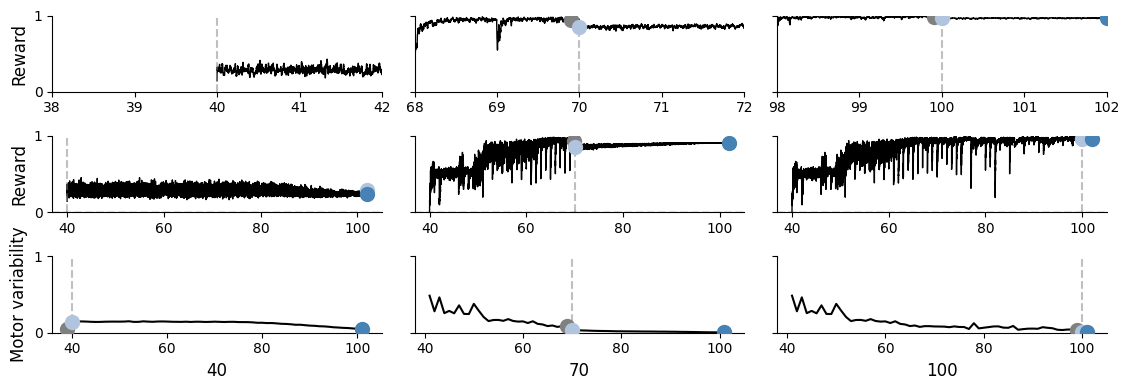

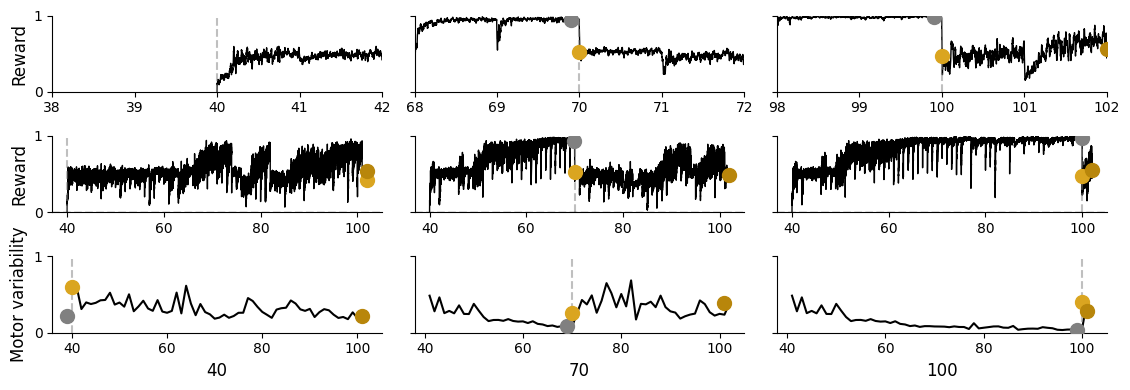

In [46]:

TRIALS = result_dict['BG_INTACT_DAYS']['rewards'][0].shape[1]
DAYS = result_dict['BG_INTACT_DAYS']['rewards'][0].shape[0]
print(f"DAYS: {DAYS}, TRIALS: {TRIALS}")

# plot_rewards_and_actions(rewards_output, actions, param_order, DAYS, TRIALS)
for param_name in result_dict:
    print(f"Plotting rewards and actions for {param_name}")
    plot_rewards_and_actions(result_dict[param_name]['rewards'], result_dict[param_name]['actions'], wanted_days , DAYS, TRIALS, smoothing=10)

    if param_name == "BG_INTACT_DAYS":
        save_figure("Figure_7a_v2", save=save_figs)
    else:
        save_figure("Figure_7d_v2", save=save_figs)

In [21]:
raise NotImplementedError("Reward and action trajectories plotted. Please review the plots and decide if you want to save them.")

NotImplementedError: Reward and action trajectories plotted. Please review the plots and decide if you want to save them.

In [ ]:
actions_array[0, 5, 0]

array([[-0.24636007,  0.38599627]])

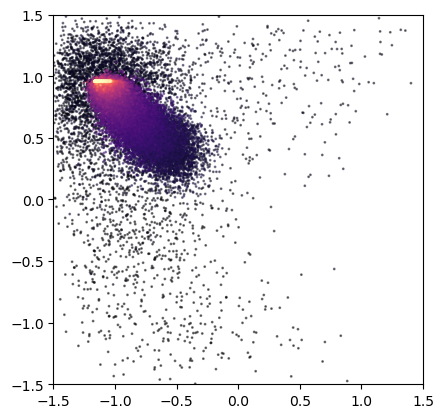

In [ ]:
lesion_type = 0
day_i = 0
day_j = 60

x = actions_array[lesion_type,day_i:day_j,:,:,0].flatten()
y = actions_array[lesion_type,day_i:day_j,:,:,1].flatten()
c = np.arange(x.shape[0])

plt.scatter(x, y, s=1, c=c, cmap='magma', alpha=0.5)
plt.ylim(-1.5, 1.5)
plt.xlim(-1.5, 1.5)
plt.gca().set_aspect('equal', adjustable='box')

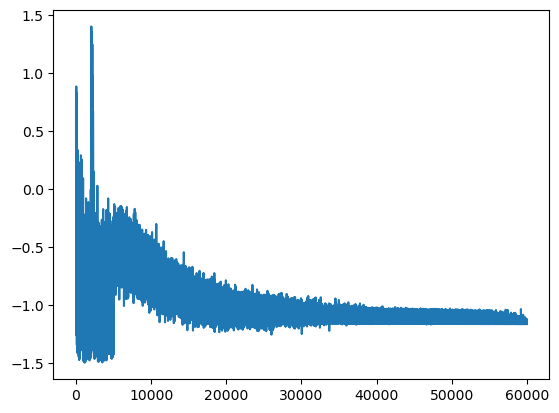

In [ ]:
plt.plot(x)

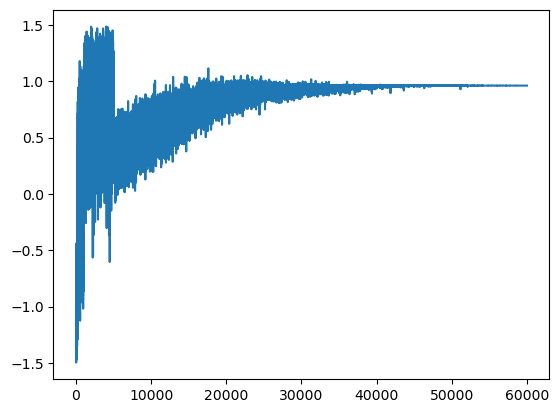

In [ ]:
plt.plot(y)

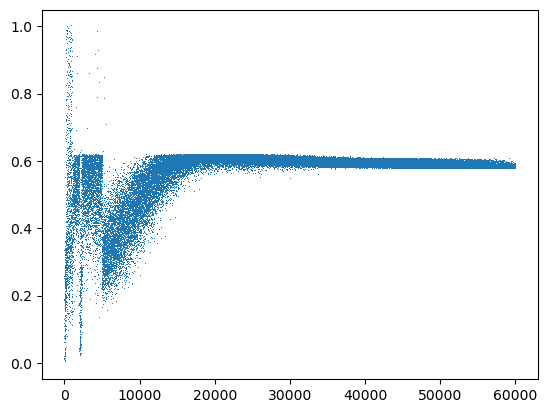

In [ ]:
plt.plot(rewards_array[lesion_type,day_i:day_j,:].flatten(), lw=0, marker=',')

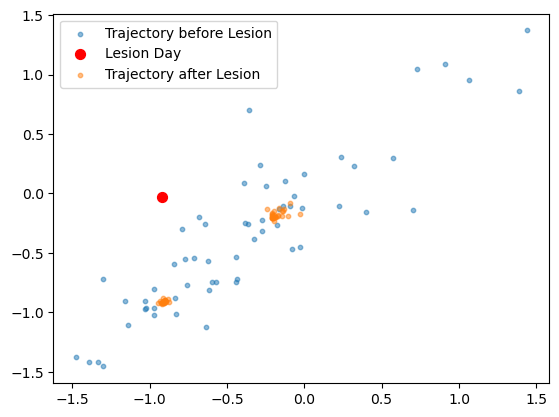

In [ ]:
# plot action via scatter 
# plot lesion day trajectory point
i = 1
index = wanted_days[i]
plt.scatter(actions_array[i, :index, 0].flatten(), actions_array[i, :index, 1].flatten(), alpha=0.5, s=10, label='Trajectory before Lesion')  # type: ignore
plt.scatter(actions_array[i, index, 0, 0, 0], actions_array[i, index, 0, 0, 1], color='red', s=50, label='Lesion Day')  # type
plt.scatter(actions_array[i, index:, 0].flatten(), actions_array[i, index:, 1].flatten(), alpha=0.5, s=10, label='Trajectory after Lesion')  # type: ignore
plt.legend()

In [ ]:
def plot_scatter_traj_alt(obj, syll, day_i, day_f, every_nth_point,
                      plot_smooth_traj = False, smooth_window=20, traj_alpha=.8, figsize=(10,10), scatter_alpha = 0.5, plot_daily_start_points = False, if_contour=False, contour_alpha=1, heatmap=False, colorbar=False, legend=False, plot_motor=True, plot_cortex=False, plot_BG=False, daycolor=False, daycolorbar=False,
                      lesion_day = None):
    fig, axs = plt.subplots(figsize=figsize)
    cmap = 'Greys'# color_contour_bckg # cmap param doesn't work # Match the colormap style from plot_landscape
    levels_ = 12 # 12 fix!
    # TRIALS = obj.TRIALS
    

    # Plot background landscape
    if obj.LANDSCAPE == 0:
        print("Plotting artificial landscape")
        plot_artificial(obj, syll, axs, levels_, cmap, if_contour=if_contour, contour_alpha=contour_alpha, heatmap=heatmap, colorbar=colorbar)
    else:
        print("Plotting syrinx landscape")
        plot_syrinx(obj, syll, axs, levels_, cmap, if_contour=if_contour, contour_alpha=contour_alpha, heatmap=heatmap, colorbar=colorbar)
    
    # Plot agent trajectory
    # axs.plot(
    #     x_traj[day_i * TRIALS: day_f * TRIALS][::every_nth_point],
    #     y_traj[day_i * TRIALS: day_f * TRIALS][::every_nth_point], color = color_motor, label='Agent Trajectory', alpha=.5, linewidth=0.0, marker='.', markersize=1
    # )
    # if plot_smooth_traj:
    #     xtraj_smooth = running_mean_dynamic(np.array(x_traj), N_i=N_i, N_f=N_f, steepness=steepness)
    #     ytraj_smooth = running_mean_dynamic(np.array(y_traj), N_i=N_i, N_f=N_f, steepness=steepness)
    #     axs.plot(
    #         xtraj_smooth[day_i * TRIALS: day_f * TRIALS], #[::every_nth_point],
    #         ytraj_smooth[day_i * TRIALS: day_f * TRIALS],#[::every_nth_point],
    #         color = color_motor, label='Motor Trajectory', alpha=.5, linewidth=0.5, marker='.', markersize=1, ls='-'
    #     )
    
    # axs.plot(
    #     x_traj[day_i * TRIALS: day_f * TRIALS][::every_nth_point],
    #     y_traj[day_i * TRIALS: day_f * TRIALS][::every_nth_point], color = 'white', label='Agent Trajectory', alpha=1, linewidth=0.0, marker='.', markersize=3, zorder=3
    # )
    # axs.plot(
    #     x_traj[day_i * TRIALS: day_f * TRIALS][::every_nth_point],
    #     y_traj[day_i * TRIALS: day_f * TRIALS][::every_nth_point], color = color_motor, label='Agent Trajectory', alpha=1, linewidth=0.0, marker='.', markersize=2, zorder=3
    # )

    if plot_motor:
        if lesion_day is None:

            x_traj, y_traj = zip(*obj.actions[:, :, syll, :].reshape(-1, 2))

            plot_scatter_traj_helper(axs,
                                    x_traj, y_traj,
                                    color_motor,
                                    alt_scatter_color = 'grey',
                                    scatter_alpha=scatter_alpha,
                                    plot_smooth_traj=plot_smooth_traj,
                                    running_smooth=smooth_window,
                                    traj_alpha=traj_alpha,
                                    day_i=day_i, day_f=day_f, every_nth_point=every_nth_point,
                                    TRIALS=obj.TRIALS,
                                    label='motor output',
                                    daycolor=daycolor,
                                    daycolorbar=daycolorbar)
        else: 
            x_traj_pre, y_traj_pre = zip(*obj.actions[:lesion_day, :, syll, :].reshape(-1, 2))
            x_traj_post, y_traj_post = zip(*obj.actions[lesion_day :, :, syll, :].reshape(-1, 2))

            plot_scatter_traj_helper(axs,
                                    x_traj_pre, y_traj_pre,
                                    "green",
                                    alt_scatter_color = 'grey',
                                    scatter_alpha=scatter_alpha,
                                    plot_smooth_traj=plot_smooth_traj,
                                    running_smooth=smooth_window,
                                    traj_alpha=traj_alpha,
                                    day_i=day_i, day_f=lesion_day, every_nth_point=every_nth_point,
                                    TRIALS=obj.TRIALS,
                                    label='motor output (pre-lesion)',
                                    daycolor=daycolor,
                                    daycolorbar=daycolorbar)
            plot_scatter_traj_helper(axs,
                                    x_traj_post, y_traj_post,
                                    "red",
                                    alt_scatter_color = 'grey',
                                    scatter_alpha=scatter_alpha,
                                    plot_smooth_traj=plot_smooth_traj,
                                    running_smooth=smooth_window,
                                    traj_alpha=traj_alpha,
                                    day_i=lesion_day, day_f=day_f, every_nth_point=every_nth_point,
                                    TRIALS=obj.TRIALS,
                                    label='motor output (post-lesion)',
                                    daycolor=daycolor,
                                    daycolorbar=daycolorbar)



    if plot_cortex:
        ra_actions = obj.actions - obj.actions_bg  
        x_ra, y_ra = zip(*ra_actions[:, :, syll, :].reshape(-1, 2))

        plot_scatter_traj_helper(axs,
                                 x_ra, y_ra,
                                 color_cortical,
                                 alt_scatter_color=sns_cmap[-1],
                                 scatter_alpha=scatter_alpha,
                                 plot_smooth_traj=plot_smooth_traj,
                                 running_smooth=smooth_window,
                                 traj_alpha=traj_alpha,
                                 day_i=day_i, day_f=day_f, every_nth_point=every_nth_point,
                                 TRIALS=obj.TRIALS,
                                 label='cortical contribution',
                                 daycolor=daycolor,
                                 daycolorbar=daycolorbar)
    

    
    if plot_BG:
        bg_actions = obj.actions_bg   
        x_bg, y_bg = zip(*bg_actions[:, :, syll, :].reshape(-1, 2))
        
        plot_scatter_traj_helper(axs,
                                 x_bg, y_bg,
                                 color_bg,
                                 alt_scatter_color='goldenrod',
                                 scatter_alpha=scatter_alpha,
                                 plot_smooth_traj=plot_smooth_traj,
                                 running_smooth=smooth_window,
                                 traj_alpha=traj_alpha,
                                 day_i=day_i, day_f=day_f, every_nth_point=every_nth_point,
                                 TRIALS=obj.TRIALS,
                                 label='BG contribution',
                                 daycolor=daycolor,
                                 daycolorbar=daycolorbar)

        if daycolor:
            axs.scatter(0, 0,
                        s=150, c='white',
                        marker='o', zorder=500)
            axs.scatter(0, 0,
                        s=50, c=color_cortical,
                        marker='o', zorder=600, label='Cortical contribution')
            


    if plot_daily_start_points:
        x = x_traj[day_i * TRIALS: day_f * TRIALS][0::1000]
        y = y_traj[day_i * TRIALS: day_f * TRIALS][0::1000]
        c_val = np.arange(len(x))
        axs.scatter(
            x, y, 200, c = 'white', label='Agent Trajectory', edgecolors='none', alpha=1, marker='.', zorder=900
        )
        axs.scatter(
            x, y, 150, c = c_val, label='Agent Trajectory', edgecolors='none', alpha=1, marker='.', zorder=1000, cmap='magma'
        )

    
    
    # Labels
    # axs.set_ylabel(r'$P$', fontsize=30)
    # axs.set_xlabel(r'$T$', fontsize=30)
    # axs.set_ylabel(r'$P_{\alpha}$ (Pressure)', fontsize=22)
    # axs.set_xlabel(r'$P_{\beta}$ (Tension)', fontsize=22)
    # axs.tick_params(labelsize=20)

    if legend:
        axs.legend(facecolor='lightgrey', bbox_to_anchor=(.8, 1.15), loc='upper left')#, edgecolor='black', framealpha=0.8)



    plt.tight_layout()